In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load the dataset — header=3 because the column names are on Excel row 4
df = pd.read_excel('PDAD UPDATED DATASET (2).xlsx', header=3)

print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nFirst 5 column names: {df.columns.tolist()[:5]}")
print(f"\nCheck if 'Employment_Status' exists: {'Employment_Status' in df.columns}")
df.head()

Loaded: 4850 rows x 42 columns

First 5 column names: ['ID_Number', 'Date_Issued', 'Date_Expired', 'Registration_No', 'Last_Name']

Check if 'Employment_Status' exists: True


,ID_Number,Date_Issued,Date_Expired,Registration_No,Last_Name,First_Name,Middle_Name,Suffix,Date_of_Birth,Age,...,Primary_Caregiver,Emergency_Contact_Name,Emergency_Contact_No,Contact_Status,PWD_ID_Status,Registration_Source,Date_Registered,Last_Updated,Verification_Status,Remarks
0,13-7401-000-0000344,2021-07-30,2026-07-30,13-7401-000-0000344,Y******,M*****,C*****,NaN,1969-09-05,56,...,Child,D***** Y******,9800047927,Updated,For Renewal,PDAD Mandaluyong,2021-07-26,2022-07-25,Flagged for Review,For renewal within current registry cycle
1,13-7401-000-0007290,2021-10-17,2026-10-17,13-7401-000-0007290,Z****,A****,P****,Jr.,2005-01-23,21,...,Self,M***** M*****,9917096425,Updated,For Renewal,PDAD Mandaluyong,2021-10-06,2023-07-17,Flagged for Review,For renewal within current registry cycle
2,13-7401-000-0005747,2023-10-08,2028-10-08,13-7401-000-0005747,Q******,C******,H*****,NaN,1968-04-07,58,...,Sibling,B***** G*******,9689565413,Updated,Active,PDAD Mandaluyong,2023-09-26,2024-04-04,Flagged for Review,Active PDAD record
3,13-7401-000-0000727,2024-02-28,2029-02-28,13-7401-000-0000727,Z*****,A**** J***,E*****,NaN,1957-10-16,68,...,Child,C****** A*** Z*****,9273423003,Updated,Active,PDAD Mandaluyong,2024-02-27,2024-12-09,Incomplete Profile,Needs contact update
4,13-7401-000-0008000,2021-05-27,2026-05-27,13-7401-000-0008000,D*****,B******,R*****,NaN,1976-03-03,50,...,Relative,S***** D*****,9562840315,Updated,For Renewal,PDAD Mandaluyong,2021-05-21,2024-02-11,Flagged for Review,For renewal within current registry cycle


In [9]:
# Filter to actually-employed people only (drops leakage)
df_ml = df[df['Employment_Status'].isin(['Employed', 'Self-employed'])].copy()

# Merge duplicate label
df_ml['Type_of_Employment'] = df_ml['Type_of_Employment'].replace({'Permanent/Regular': 'Permanent'})

# Fill missing assistive device with "None"
df_ml['Current_Assistive_Device'] = df_ml['Current_Assistive_Device'].fillna('None')

print(f"Final dataset: {len(df_ml)} rows")
print(f"\nTarget distribution:")
print(df_ml['Type_of_Employment'].value_counts())

Final dataset: 1585 rows

Target distribution:
Type_of_Employment
Self-employed    604
Permanent        310
Contractual      223
Job Order        167
Casual           119
Probationary      99
Seasonal          63
Name: count, dtype: int64


In [10]:
print("=== Current_Assistive_Device vs Type_of_Employment ===")
print(pd.crosstab(df_ml['Current_Assistive_Device'], df_ml['Type_of_Employment']))

=== Current_Assistive_Device vs Type_of_Employment ===
Type_of_Employment        Casual  Contractual  Job Order  Permanent  \
Current_Assistive_Device                                              
Cane                          14            5         20         21   
Crutches                      12            0          2          0   
Eyeglasses                     0           16          0         37   
Hearing Aid                    0           23          0         43   
None                          13          155         58        184   
Others                        80            0         74         20   
Prosthesis                     0            0          0          0   
Walker                         0           13          0          5   
Wheelchair                     0           11         13          0   

Type_of_Employment        Probationary  Seasonal  Self-employed  
Current_Assistive_Device                                         
Cane                           

In [11]:
features = ['Age', 'Sex', 'Civil_Status', 'Disability_Type', 'Disability_Visibility',
            'Cause_of_Disability', 'Educational_Attainment', 'Skills',
            'Mobility_Status', 'Current_Assistive_Device', 'Occupation_Group']
target = 'Type_of_Employment'

X = df_ml[features].copy()
y = df_ml[target].copy()

categorical_cols = [col for col in features if col != 'Age']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

print(f"Total features after encoding: {X_encoded.shape[1]}")

Total features after encoding: 108


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {len(X_train)} rows")
print(f"Test:  {len(X_test)} rows")

Train: 1268 rows
Test:  317 rows


In [13]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Model trained.")

Model trained.


Accuracy: 0.4669

=== Classification Report ===
               precision    recall  f1-score   support

       Casual       0.37      0.67      0.48        24
  Contractual       0.44      0.82      0.58        44
    Job Order       0.47      0.55      0.51        33
    Permanent       0.58      0.68      0.62        62
 Probationary       0.39      0.45      0.42        20
     Seasonal       0.36      0.77      0.49        13
Self-employed       0.55      0.14      0.22       121

     accuracy                           0.47       317
    macro avg       0.45      0.58      0.47       317
 weighted avg       0.50      0.47      0.42       317

=== Confusion Matrix ===
               Casual  Contractual  Job Order  Permanent  Probationary  \
Casual             16            0          4          0             1   
Contractual         0           36          3          2             0   
Job Order           5            6         18          1             1   
Permanent           2  

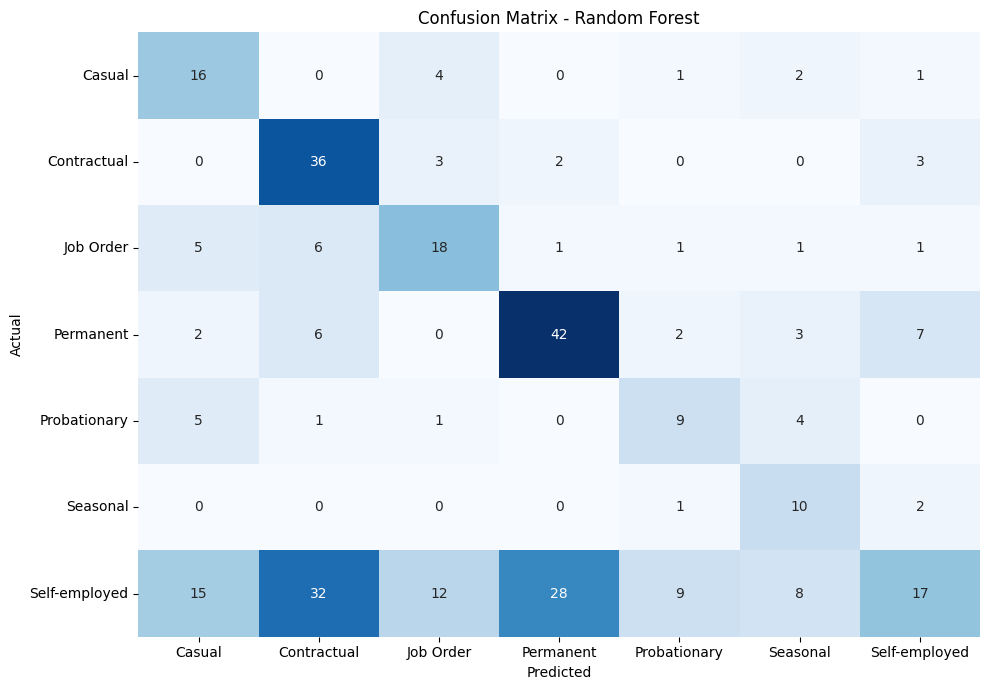

In [14]:
y_pred = rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
cm_df = pd.DataFrame(cm, index=rf.classes_, columns=rf.classes_)
print(cm_df)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

=== Top 20 Most Important Features ===
                                               feature  importance
102                            Occupation_Group_Others    0.108165
94                     Current_Assistive_Device_Others    0.063660
0                                                  Age    0.059501
93                       Current_Assistive_Device_None    0.044235
98           Occupation_Group_Clerical Support Workers    0.034064
99   Occupation_Group_Craft and Related Trades Workers    0.033659
100            Occupation_Group_Elementary Occupations    0.029692
107  Occupation_Group_Technicians and Associate Pro...    0.024440
8              Disability_Type_Deaf or Hard of Hearing    0.023514
105         Occupation_Group_Service and Sales Workers    0.023235
15      Disability_Type_Speech and Language Disability    0.019875
106  Occupation_Group_Skilled Agricultural, Forestr...    0.015980
17                      Disability_Visibility_Apparent    0.015730
18                  Dis

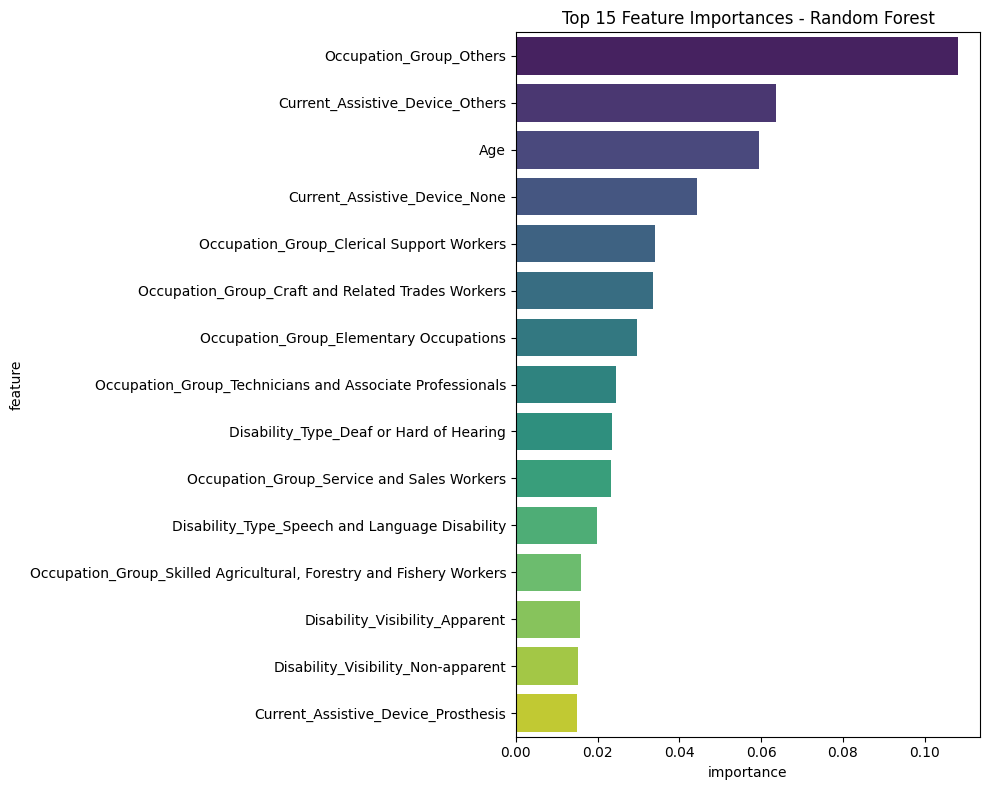

In [15]:
importances = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("=== Top 20 Most Important Features ===")
print(importances.head(20))

plt.figure(figsize=(10, 8))
top_15 = importances.head(15)
sns.barplot(data=top_15, x='importance', y='feature', hue='feature', palette='viridis', legend=False)
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
cv_scores = cross_val_score(rf, X_encoded, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f"5-Fold Cross-Validation Accuracy:")
print(f"  Mean: {cv_scores.mean():.4f}")
print(f"  Std:  {cv_scores.std():.4f}")
print(f"  Individual folds: {cv_scores}")

5-Fold Cross-Validation Accuracy:
  Mean: 0.4915
  Std:  0.0131
  Individual folds: [0.50788644 0.48580442 0.47003155 0.49211356 0.50157729]


In [17]:
joblib.dump(rf, 'rf_model_v1.joblib')
joblib.dump(X_encoded.columns.tolist(), 'rf_feature_columns.joblib')
joblib.dump(rf.classes_.tolist(), 'rf_classes.joblib')

print(f"Saved: rf_model_v1.joblib")
print(f"  Features: {X_encoded.shape[1]}")
print(f"  Classes:  {len(rf.classes_)}")

Saved: rf_model_v1.joblib
  Features: 108
  Classes:  7


In [18]:
# Export the FULL cleaned PDAD dataset for Member 3's registry import
# This is different from df_ml (filtered for ML training only)

df_registry = df.copy()

# Drop the 2 columns flagged as DROP in our column mapping
df_registry = df_registry.drop(columns=['Registration_No', 'Registration_Source'])

# Standardize the Type_of_Employment label
df_registry['Type_of_Employment'] = df_registry['Type_of_Employment'].replace(
    {'Permanent/Regular': 'Permanent'}
)

# Fill missing Current_Assistive_Device with 'None'
df_registry['Current_Assistive_Device'] = df_registry['Current_Assistive_Device'].fillna('None')

# Convert column names to lowercase snake_case
df_registry.columns = [c.lower() for c in df_registry.columns]

# Export
df_registry.to_csv('PDAD_for_registry.csv', index=False, encoding='utf-8')

print(f"Exported: {len(df_registry)} rows x {len(df_registry.columns)} columns")
print(f"\nColumns: {df_registry.columns.tolist()}")

Exported: 4850 rows x 40 columns

Columns: ['id_number', 'date_issued', 'date_expired', 'last_name', 'first_name', 'middle_name', 'suffix', 'date_of_birth', 'age', 'blood_type', 'place_of_birth', 'sex', 'civil_status', 'religion', 'nationality', 'mobile_no', 'address', 'barangay', 'city', 'disability_type', 'disability_visibility', 'cause_of_disability', 'educational_attainment', 'employment_status', 'type_of_employment', 'occupation_group', 'skills', 'organization_affiliation', 'current_assistive_device', 'mobility_status', 'total_family_members', 'primary_caregiver', 'emergency_contact_name', 'emergency_contact_no', 'contact_status', 'pwd_id_status', 'date_registered', 'last_updated', 'verification_status', 'remarks']
